In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/listings_raw.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 48895 rows, 16 columns


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [11]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


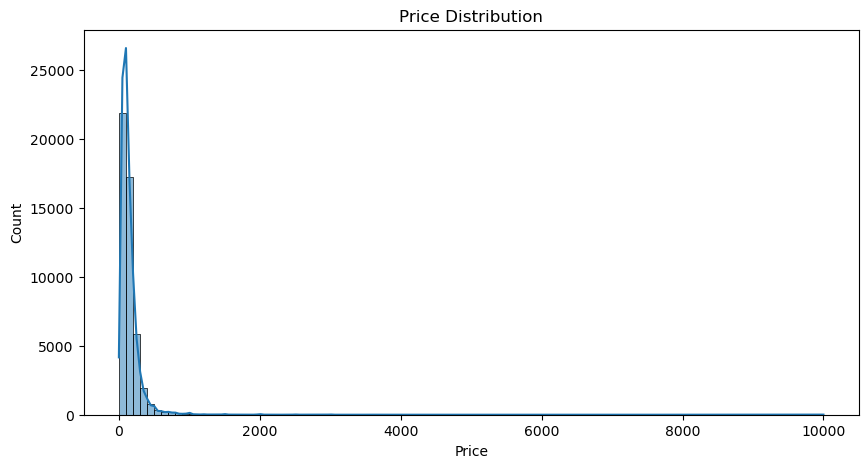

Min price: 0
Max price: 10000
Mean price: 152.72


In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=100, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.show()

print(f"Min price: {df['price'].min()}")
print(f"Max price: {df['price'].max()}")
print(f"Mean price: {df['price'].mean():.2f}")

In [13]:
# Remove listings with price = 0 or price > 1000
df = df[df['price'] > 0]
df = df[df['price'] <= 1000]
print(f"After removing outliers: {df.shape[0]} rows")

After removing outliers: 48645 rows


In [14]:
# Fill missing reviews with 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Create has_reviews flag
df['has_reviews'] = df['number_of_reviews'].apply(lambda x: 1 if x > 0 else 0)

# Drop columns not useful for modeling
df = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
has_reviews                       0
dtype: int64


In [15]:
# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type'], drop_first=True)

print(f"Final dataset shape: {df.shape}")
print(df.head())

Final dataset shape: (48645, 16)
  neighbourhood  latitude  longitude  price  minimum_nights  \
0    Kensington  40.64749  -73.97237    149               1   
1       Midtown  40.75362  -73.98377    225               1   
2        Harlem  40.80902  -73.94190    150               3   
3  Clinton Hill  40.68514  -73.95976     89               1   
4   East Harlem  40.79851  -73.94399     80              10   

   number_of_reviews  reviews_per_month  calculated_host_listings_count  \
0                  9               0.21                               6   
1                 45               0.38                               2   
2                  0               0.00                               1   
3                270               4.64                               1   
4                  9               0.10                               1   

   availability_365  has_reviews  neighbourhood_group_Brooklyn  \
0               365            1                          True   
1    

In [16]:
df.to_csv('../data/listings_clean.csv', index=False)
print("Cleaned data saved to data/listings_clean.csv")

Cleaned data saved to data/listings_clean.csv
